In [7]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [8]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [9]:
base_path = f'../../data/{NUTS2}/results/'

In [10]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['IT_Veneto_Results_2008-2019.csv',
 'IT_Veneto_Results_2023-August-1st_(new).csv',
 'IT_Veneto_Results_2023-August-2nd_(new).csv',
 'IT_Veneto_Results_2023-July-1st.csv',
 'IT_Veneto_Results_2023-July-1st_(new).csv',
 'IT_Veneto_Results_2023-July-2nd.csv',
 'IT_Veneto_Results_2023-July-2nd_(new).csv',
 'IT_Veneto_Results_2023-June-1st.csv',
 'IT_Veneto_Results_2023-June-1st_(new).csv',
 'IT_Veneto_Results_2023-June-2nd.csv',
 'IT_Veneto_Results_2023-June-2nd_(new).csv',
 'IT_Veneto_Results_2023-May-1st.csv',
 'IT_Veneto_Results_2023-May-1st_(new).csv',
 'IT_Veneto_Results_2023-May-2nd.csv',
 'IT_Veneto_Results_2023-May-2nd_(new).csv']

In [11]:
del file_list[3:15:2]

In [12]:
file_list

['IT_Veneto_Results_2008-2019.csv',
 'IT_Veneto_Results_2023-August-1st_(new).csv',
 'IT_Veneto_Results_2023-August-2nd_(new).csv',
 'IT_Veneto_Results_2023-July-1st_(new).csv',
 'IT_Veneto_Results_2023-July-2nd_(new).csv',
 'IT_Veneto_Results_2023-June-1st_(new).csv',
 'IT_Veneto_Results_2023-June-2nd_(new).csv',
 'IT_Veneto_Results_2023-May-1st_(new).csv',
 'IT_Veneto_Results_2023-May-2nd_(new).csv']

In [13]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [14]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

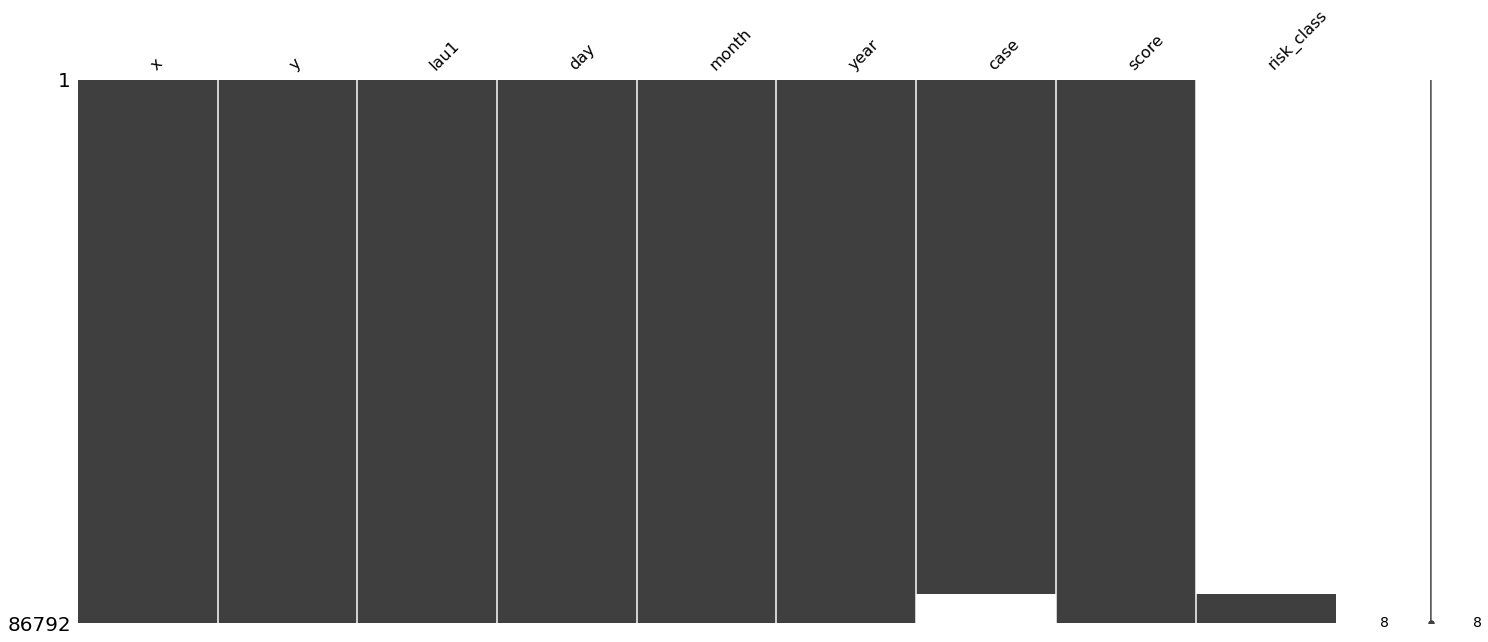

In [15]:
missingno.matrix(concated)

In [16]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [17]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [18]:
years = np.sort(concated.year.unique())
years

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2023], dtype=int64)

In [19]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 8)].copy()

In [20]:
#condition = df[(df['month'] == 8) & (df['day'] == 16)].index
#df.drop(condition, inplace = True)
df

,x,y,lau1,day,month,year,case,score,risk_class
0,12.64550,45.53937,jesolo,16,8,2018,0.0,9.989788e-01,NaN
1,12.64884,45.68374,ceggia,16,8,2018,0.0,9.982185e-01,NaN
2,12.62107,45.75752,motta da livenza,16,8,2018,0.0,9.980037e-01,NaN
3,12.54296,45.67127,noventa da piave,16,8,2018,0.0,9.979486e-01,NaN
4,12.89482,45.63839,caorle,16,8,2018,0.0,9.974389e-01,NaN
...,...,...,...,...,...,...,...,...,...
86787,11.39118,45.89987,rotzo,16,5,2023,NaN,8.338114e-11,0.0
86788,12.42616,46.50321,lozzo da cadore,16,5,2023,NaN,7.434996e-11,0.0
86789,12.05493,46.45349,selva da cadore,16,5,2023,NaN,5.985187e-11,0.0
86790,11.71465,46.07125,lamon,16,5,2023,NaN,4.990256e-11,0.0


In [21]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.2916874171585726, 0.7128345091584661, 0.8345479844283598, 0.9597101609376664, 0.983219513129097, 1.0]


In [22]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,x,y,lau1,day,month,year,case,score,risk_class
0,12.64550,45.53937,jesolo,16,8,2018,0.0,0.998979,5
1,12.64884,45.68374,ceggia,16,8,2018,0.0,0.998218,5
2,12.62107,45.75752,motta da livenza,16,8,2018,0.0,0.998004,5
3,12.54296,45.67127,noventa da piave,16,8,2018,0.0,0.997949,5
4,12.89482,45.63839,caorle,16,8,2018,0.0,0.997439,5
5,12.90843,45.79186,fossalta da portogruaro,16,8,2018,0.0,0.997359,5
7,12.06743,45.59640,trebaseleghe,16,8,2018,0.0,0.996887,5
8,11.94104,45.59872,loreggia,16,8,2018,0.0,0.996886,5
9,12.08695,45.41946,dolo,16,8,2018,1.0,0.996698,5
11,12.19583,45.72222,ponzano veneto,16,8,2018,0.0,0.996272,5


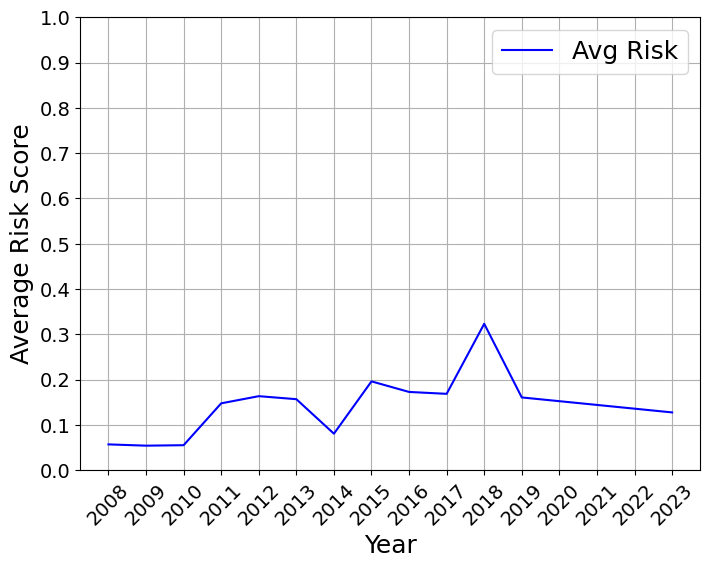

In [23]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [24]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 4)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,x,y,lau1,day,month,year,case,score,risk_class


In [25]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 4)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,x,y,lau1,day,month,year,case,score,risk_class
0,11.73897,44.96915,polesella,1,8,2023,NaN,0.961662,4
1,11.73897,44.96915,polesella,16,8,2023,NaN,0.991146,5
2,12.62107,45.75752,motta da livenza,16,8,2023,NaN,0.969150,4
3,12.64550,45.53937,jesolo,16,8,2023,NaN,0.964405,4
4,11.87982,45.22842,conselve,16,8,2023,NaN,0.963664,4
5,12.22945,45.56416,mogliano veneto,16,8,2023,NaN,0.962215,4
